# Simulación del sistema de parqueaderos

En este notebook se construye una simulación del sistema de pago de parqueaderos del centro comercial Supercentro. La idea es analizar el comportamiento de tres cajeros independientes y revisar, con base en resultados estadísticos, si son suficientes para atender la demanda de usuarios.

El modelo trabaja con cuatro tipos de usuarios: rápidos, normales, lentos y muy lentos. Cada grupo tiene tiempos diferentes de llegada y de uso del cajero, por eso es importante simular el sistema antes de tomar una decisión.

## Preparación del entorno

Primero se importan las librerías necesarias para simular, organizar datos, calcular estadísticas y generar gráficas.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

## Parámetros iniciales del modelo

En esta sección se registran los datos base del problema: número de cajeros, tiempo de simulación, cantidad de réplicas y características de cada tipo de usuario.

El tiempo de simulación se define en 1000 minutos por réplica, tomando como referencia el documento anexo del laboratorio. Las 120 réplicas permiten observar mejor el comportamiento promedio del sistema.

In [3]:
NUM_CAJEROS = 3
TIEMPO_SIMULACION = 1000
NUM_REPLICAS = 120

SEED_BASE = 2026

In [4]:
usuarios = {
    "Rapido": {
        "media_servicio": 1.0,
        "media_llegada": 3.0,
        "probabilidad": 0.25
    },
    "Normal": {
        "media_servicio": 3.0,
        "media_llegada": 3.0,
        "probabilidad": 0.20
    },
    "Lento": {
        "media_servicio": 4.0,
        "media_llegada": 5.0,
        "probabilidad": 0.275
    },
    "Muy lento": {
        "media_servicio": 6.0,
        "media_llegada": 7.0,
        "probabilidad": 0.275
    }
}

In [5]:
tabla_parametros = []

for tipo, datos in usuarios.items():
    media_servicio = datos["media_servicio"]
    media_llegada = datos["media_llegada"]

    # Conversión a tasas
    lambda_llegada = 1 / media_llegada
    mu_servicio = 1 / media_servicio
    rho = lambda_llegada / mu_servicio

    tabla_parametros.append({
        "Tipo de usuario": tipo,
        "Media servicio (min)": media_servicio,
        "Media llegada (min)": media_llegada,
        "Probabilidad": datos["probabilidad"],
        "Lambda λ": lambda_llegada,
        "Mu μ": mu_servicio,
        "Rho ρ": rho
    })

tabla_parametros = pd.DataFrame(tabla_parametros)

tabla_parametros

,Tipo de usuario,Media servicio (min),Media llegada (min),Probabilidad,Lambda λ,Mu μ,Rho ρ
0,Rapido,1.0,3.0,0.250,0.333333,1.000000,0.333333
1,Normal,3.0,3.0,0.200,0.333333,0.333333,1.000000
2,Lento,4.0,5.0,0.275,0.200000,0.250000,0.800000
3,Muy lento,6.0,7.0,0.275,0.142857,0.166667,0.857143


In [6]:
tabla_parametros["Probabilidad"].sum()

np.float64(1.0)

In [7]:
tabla_parametros.round(3)

,Tipo de usuario,Media servicio (min),Media llegada (min),Probabilidad,Lambda λ,Mu μ,Rho ρ
0,Rapido,1.0,3.0,0.250,0.333,1.000,0.333
1,Normal,3.0,3.0,0.200,0.333,0.333,1.000
2,Lento,4.0,5.0,0.275,0.200,0.250,0.800
3,Muy lento,6.0,7.0,0.275,0.143,0.167,0.857


La tabla muestra que los usuarios normales se encuentran en un punto crítico, ya que su factor de utilización es igual a 1. Los usuarios lentos y muy lentos también requieren atención especial porque, aunque su factor es menor que 1, representan más de la mitad de los usuarios del sistema.

## Simulación de una réplica

En esta parte se construye la función principal de simulación. Una réplica representa una corrida completa del sistema durante 1000 minutos.

En cada réplica se generan usuarios de forma aleatoria, se asigna un tipo de usuario según las probabilidades definidas y luego se envía a uno de los tres cajeros. Para cada usuario se registran los tiempos principales: llegada, inicio de atención, finalización, espera, servicio y tiempo total en el sistema.

In [8]:
def simular_replica(replica_id, tiempo_simulacion=TIEMPO_SIMULACION, num_cajeros=NUM_CAJEROS, seed=None):
    rng = np.random.default_rng(seed)

    tipos_usuarios = list(usuarios.keys())
    probabilidades = [usuarios[tipo]["probabilidad"] for tipo in tipos_usuarios]

    # Disponibilidad inicial de cada cajero.
    # Al inicio todos están libres en el minuto 0.
    disponibilidad_cajero = np.zeros(num_cajeros)

    tiempo_actual = 0
    usuario_id = 0
    registros = []

    while tiempo_actual < tiempo_simulacion:
        # Se selecciona aleatoriamente el tipo de usuario.
        tipo_usuario = rng.choice(tipos_usuarios, p=probabilidades)

        media_llegada = usuarios[tipo_usuario]["media_llegada"]
        media_servicio = usuarios[tipo_usuario]["media_servicio"]

        # Se genera el tiempo hasta la próxima llegada.
        tiempo_entre_llegadas = rng.exponential(media_llegada)
        tiempo_actual += tiempo_entre_llegadas

        if tiempo_actual > tiempo_simulacion:
            break

        # Se asigna el usuario a uno de los cajeros.
        cajero = rng.integers(1, num_cajeros + 1)

        # Se genera el tiempo de servicio.
        tiempo_servicio = rng.exponential(media_servicio)

        # El usuario inicia atención cuando llega o cuando el cajero queda libre.
        inicio_atencion = max(tiempo_actual, disponibilidad_cajero[cajero - 1])

        # Tiempo esperando en fila.
        tiempo_espera = inicio_atencion - tiempo_actual

        # Fin de atención.
        fin_atencion = inicio_atencion + tiempo_servicio

        # Tiempo total en el sistema.
        tiempo_sistema = fin_atencion - tiempo_actual

        # Actualizar disponibilidad del cajero.
        disponibilidad_cajero[cajero - 1] = fin_atencion

        usuario_id += 1

        registros.append({
            "replica": replica_id,
            "usuario_id": usuario_id,
            "tipo_usuario": tipo_usuario,
            "cajero": cajero,
            "tiempo_llegada": tiempo_actual,
            "inicio_atencion": inicio_atencion,
            "fin_atencion": fin_atencion,
            "tiempo_servicio": tiempo_servicio,
            "tiempo_espera": tiempo_espera,
            "tiempo_sistema": tiempo_sistema
        })

    return pd.DataFrame(registros)

In [9]:
df_prueba = simular_replica(
    replica_id=1,
    tiempo_simulacion=TIEMPO_SIMULACION,
    num_cajeros=NUM_CAJEROS,
    seed=SEED_BASE
)

df_prueba.head()

,replica,usuario_id,tipo_usuario,cajero,tiempo_llegada,inicio_atencion,fin_atencion,tiempo_servicio,tiempo_espera,tiempo_sistema
0,1,1,Rapido,2,3.797192,3.797192,4.483520,0.686328,0.0,0.686328
1,1,2,Normal,2,7.002057,7.002057,10.856516,3.854459,0.0,3.854459
2,1,3,Rapido,1,9.737140,9.737140,11.426078,1.688938,0.0,1.688938
3,1,4,Muy lento,1,19.345257,19.345257,22.033814,2.688557,0.0,2.688557
4,1,5,Lento,2,22.092540,22.092540,25.826117,3.733577,0.0,3.733577


In [10]:
print("Usuarios atendidos en la réplica:", len(df_prueba))
print("Cajeros utilizados:", sorted(df_prueba["cajero"].unique()))
print("Tipos de usuario generados:", df_prueba["tipo_usuario"].unique())

df_prueba.describe()

Usuarios atendidos en la réplica: 189
Cajeros utilizados: [np.int64(1), np.int64(2), np.int64(3)]
Tipos de usuario generados: [np.str_('Rapido') np.str_('Normal') np.str_('Muy lento') np.str_('Lento')]


,replica,usuario_id,cajero,tiempo_llegada,inicio_atencion,fin_atencion,tiempo_servicio,tiempo_espera,tiempo_sistema
count,189.0,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000,189.000000
mean,1.0,95.000000,1.952381,523.634895,525.198376,529.126407,3.928031,1.563481,5.491512
std,0.0,54.703748,0.794166,275.015803,275.283578,275.543930,4.138040,3.742437,5.316093
min,1.0,1.000000,1.000000,3.797192,3.797192,4.483520,0.014006,0.000000,0.014006
25%,1.0,48.000000,1.000000,303.607280,304.607600,307.187198,1.130806,0.000000,1.555208
50%,1.0,95.000000,2.000000,544.891894,561.652900,565.700434,2.614181,0.000000,3.717107
75%,1.0,142.000000,3.000000,728.820919,729.099319,739.508545,5.014050,0.570664,7.748131
max,1.0,189.000000,3.000000,998.170726,998.170726,999.370109,18.668839,20.833742,23.240609


In [11]:
columnas_tiempo = [
    "tiempo_llegada",
    "inicio_atencion",
    "fin_atencion",
    "tiempo_servicio",
    "tiempo_espera",
    "tiempo_sistema"
]

(df_prueba[columnas_tiempo] < 0).sum()

,0
tiempo_llegada,0
inicio_atencion,0
fin_atencion,0
tiempo_servicio,0
tiempo_espera,0
tiempo_sistema,0


La prueba inicial permite verificar que la simulación genera usuarios, asigna cajeros y calcula los tiempos principales del sistema. También se revisa que no existan tiempos negativos, lo cual indica que la lógica básica de llegada, espera y atención está funcionando correctamente.

## Ejecución de múltiples réplicas

Después de probar una sola réplica, se ejecutan varias corridas del modelo. Cada réplica representa una simulación independiente del sistema durante 1000 minutos.

Trabajar con varias réplicas permite reducir el efecto del azar y obtener resultados más estables para analizar tiempos de espera, tiempos de servicio, tiempos en el sistema y cantidad de usuarios atendidos.

In [12]:
def ejecutar_simulacion(num_replicas=NUM_REPLICAS):
    """
    Se ejecutan varias réplicas del modelo y se consolidan todos los resultados
    en un solo DataFrame.
    """

    resultados = []

    for replica in range(1, num_replicas + 1):
        df_replica = simular_replica(
            replica_id=replica,
            tiempo_simulacion=TIEMPO_SIMULACION,
            num_cajeros=NUM_CAJEROS,
            seed=SEED_BASE + replica
        )

        resultados.append(df_replica)

    df_resultados = pd.concat(resultados, ignore_index=True)

    return df_resultados

In [13]:
df_resultados = ejecutar_simulacion()

df_resultados.head()

,replica,usuario_id,tipo_usuario,cajero,tiempo_llegada,inicio_atencion,fin_atencion,tiempo_servicio,tiempo_espera,tiempo_sistema
0,1,1,Rapido,1,4.428615,4.428615,5.223429,0.794814,0.0,0.794814
1,1,2,Normal,1,5.763218,5.763218,6.305630,0.542412,0.0,0.542412
2,1,3,Lento,1,9.680064,9.680064,9.729200,0.049135,0.0,0.049135
3,1,4,Normal,1,15.979622,15.979622,16.089181,0.109558,0.0,0.109558
4,1,5,Muy lento,2,25.023665,25.023665,27.420462,2.396797,0.0,2.396797


In [14]:
print("Total de usuarios simulados:", len(df_resultados))
print("Cantidad de réplicas:", df_resultados["replica"].nunique())
print("Usuarios promedio por réplica:", round(df_resultados.groupby("replica").size().mean(), 2))
print("Cajeros utilizados:", sorted(df_resultados["cajero"].unique()))
print("Tipos de usuario:", df_resultados["tipo_usuario"].unique())

Total de usuarios simulados: 25952
Cantidad de réplicas: 120
Usuarios promedio por réplica: 216.27
Cajeros utilizados: [np.int64(1), np.int64(2), np.int64(3)]
Tipos de usuario: [np.str_('Rapido') np.str_('Normal') np.str_('Lento') np.str_('Muy lento')]


In [15]:
columnas_tiempo = [
    "tiempo_llegada",
    "inicio_atencion",
    "fin_atencion",
    "tiempo_servicio",
    "tiempo_espera",
    "tiempo_sistema"
]

(df_resultados[columnas_tiempo] < 0).sum()

,0
tiempo_llegada,0
inicio_atencion,0
fin_atencion,0
tiempo_servicio,0
tiempo_espera,0
tiempo_sistema,0


In [16]:
df_resultados[
    ["tiempo_servicio", "tiempo_espera", "tiempo_sistema"]
].describe().round(3)

,tiempo_servicio,tiempo_espera,tiempo_sistema
count,25952.000,25952.000,25952.000
mean,3.557,1.564,5.121
std,4.402,4.154,5.978
min,0.000,0.000,0.000
25%,0.716,0.000,1.077
50%,1.986,0.000,3.044
75%,4.718,0.361,7.023
max,61.252,48.706,69.815


La ejecución de múltiples réplicas permite contar con una base de datos más amplia para el análisis. En esta revisión general se confirma que el modelo genera usuarios en las 120 réplicas, utiliza los tres cajeros disponibles y no produce tiempos negativos, por lo que la simulación puede usarse para calcular las estadísticas solicitadas.

## Estadísticas por cajero

En esta sección se calculan las estadísticas principales para cada cajero. Esto permite comparar el desempeño de los tres cajeros y determinar cuál presenta menor y mayor tiempo promedio.

Se analizan tres tiempos:

- Tiempo de servicio: tiempo que el usuario tarda usando el cajero.
- Tiempo de espera: tiempo que el usuario espera antes de ser atendido.
- Tiempo en sistema: tiempo total desde que llega hasta que termina su atención.

In [17]:
def intervalo_confianza_95(serie):

    datos = pd.Series(serie).dropna()
    n = len(datos)

    if n < 2:
        return pd.Series({
            "n": n,
            "media": np.nan,
            "desviacion": np.nan,
            "ic95_inf": np.nan,
            "ic95_sup": np.nan
        })

    media = datos.mean()
    desviacion = datos.std(ddof=1)

    t_critico = stats.t.ppf(0.975, n - 1)
    margen_error = t_critico * desviacion / np.sqrt(n)

    return pd.Series({
        "n": n,
        "media": media,
        "desviacion": desviacion,
        "ic95_inf": media - margen_error,
        "ic95_sup": media + margen_error
    })

In [18]:
def resumen_por_cajero(data):

    resumen = []

    for cajero, grupo in data.groupby("cajero"):
        fila = {
            "cajero": cajero,
            "usuarios_atendidos": len(grupo)
        }

        for variable in ["tiempo_servicio", "tiempo_espera", "tiempo_sistema"]:
            estadisticos = intervalo_confianza_95(grupo[variable])

            fila[f"{variable}_media"] = estadisticos["media"]
            fila[f"{variable}_desviacion"] = estadisticos["desviacion"]
            fila[f"{variable}_min"] = grupo[variable].min()
            fila[f"{variable}_max"] = grupo[variable].max()
            fila[f"{variable}_ic95_inf"] = estadisticos["ic95_inf"]
            fila[f"{variable}_ic95_sup"] = estadisticos["ic95_sup"]

        resumen.append(fila)

    return pd.DataFrame(resumen)

In [19]:
resumen_cajeros = resumen_por_cajero(df_resultados)

resumen_cajeros.round(3)

,cajero,usuarios_atendidos,tiempo_servicio_media,tiempo_servicio_desviacion,tiempo_servicio_min,tiempo_servicio_max,tiempo_servicio_ic95_inf,tiempo_servicio_ic95_sup,tiempo_espera_media,tiempo_espera_desviacion,tiempo_espera_min,tiempo_espera_max,tiempo_espera_ic95_inf,tiempo_espera_ic95_sup,tiempo_sistema_media,tiempo_sistema_desviacion,tiempo_sistema_min,tiempo_sistema_max,tiempo_sistema_ic95_inf,tiempo_sistema_ic95_sup
0,1,8539,3.553,4.444,0.000,61.252,3.459,3.648,1.515,4.245,0.0,48.706,1.425,1.605,5.068,6.108,0.000,69.815,4.939,5.198
1,2,8762,3.552,4.360,0.001,47.398,3.460,3.643,1.558,4.082,0.0,41.125,1.472,1.643,5.109,5.858,0.002,49.665,4.987,5.232
2,3,8651,3.567,4.403,0.000,44.812,3.474,3.660,1.617,4.138,0.0,43.613,1.530,1.704,5.184,5.968,0.000,52.563,5.058,5.310


In [20]:
resumen_cajeros_simple = resumen_cajeros[
    [
        "cajero",
        "usuarios_atendidos",
        "tiempo_servicio_media",
        "tiempo_espera_media",
        "tiempo_sistema_media",
        "tiempo_sistema_ic95_inf",
        "tiempo_sistema_ic95_sup"
    ]
].copy()

resumen_cajeros_simple.round(3)

,cajero,usuarios_atendidos,tiempo_servicio_media,tiempo_espera_media,tiempo_sistema_media,tiempo_sistema_ic95_inf,tiempo_sistema_ic95_sup
0,1,8539,3.553,1.515,5.068,4.939,5.198
1,2,8762,3.552,1.558,5.109,4.987,5.232
2,3,8651,3.567,1.617,5.184,5.058,5.310


In [21]:
cajero_menor_tiempo = resumen_cajeros_simple.loc[
    resumen_cajeros_simple["tiempo_sistema_media"].idxmin()
]

cajero_mayor_tiempo = resumen_cajeros_simple.loc[
    resumen_cajeros_simple["tiempo_sistema_media"].idxmax()
]

print("Cajero con menor tiempo promedio en sistema:")
print(cajero_menor_tiempo[["cajero", "tiempo_sistema_media"]])

print("\nCajero con mayor tiempo promedio en sistema:")
print(cajero_mayor_tiempo[["cajero", "tiempo_sistema_media"]])

Cajero con menor tiempo promedio en sistema:
cajero                  1.000000
tiempo_sistema_media    5.068418
Name: 0, dtype: float64

Cajero con mayor tiempo promedio en sistema:
cajero                  3.000000
tiempo_sistema_media    5.184086
Name: 2, dtype: float64


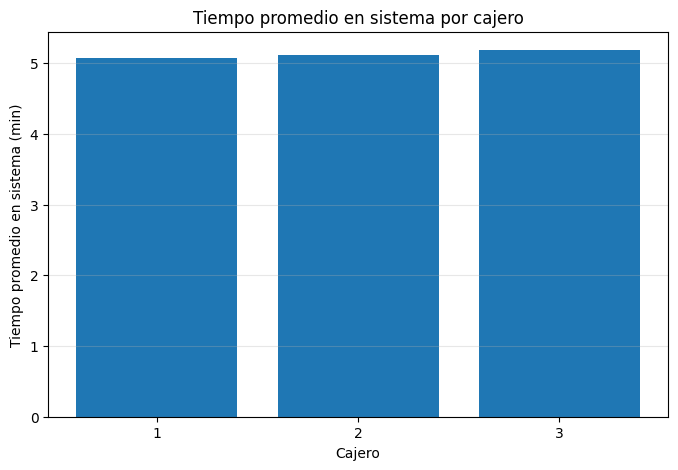

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_cajeros_simple["cajero"].astype(str),
    resumen_cajeros_simple["tiempo_sistema_media"]
)

plt.title("Tiempo promedio en sistema por cajero")
plt.xlabel("Cajero")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.grid(axis="y", alpha=0.3)

plt.show()

Con las estadísticas por cajero se puede comparar el comportamiento de las tres filas independientes. Para este análisis se toma como referencia el tiempo promedio en sistema, ya que incluye tanto el tiempo de espera como el tiempo de servicio.

El cajero con menor tiempo promedio representa la fila con mejor desempeño durante la simulación, mientras que el cajero con mayor tiempo promedio permite identificar dónde se presentó mayor congestión.

## Promedio de usuarios por tipo

En esta sección se analiza cuántos usuarios de cada tipo fueron atendidos en la simulación. Esto permite verificar si la distribución generada se acerca a las probabilidades definidas en el problema: 25% rápidos, 20% normales, 27.5% lentos y 27.5% muy lentos.

El cálculo se realiza sobre la totalidad de cajeros, ya que el punto solicitado no pide separar los usuarios por cajero sino analizar el sistema completo.

In [23]:
usuarios_por_tipo_replica = (
    df_resultados
    .groupby(["replica", "tipo_usuario"])
    .size()
    .unstack(fill_value=0)
)

usuarios_por_tipo_replica.head()

tipo_usuario,Lento,Muy lento,Normal,Rapido
replica,,,,
1,66,55,46,57
2,65,54,50,55
3,64,52,35,55
4,57,57,54,58
5,61,59,44,59


In [24]:
promedio_usuarios_tipo = usuarios_por_tipo_replica.mean().reset_index()

promedio_usuarios_tipo.columns = [
    "tipo_usuario",
    "promedio_usuarios_por_replica"
]

promedio_usuarios_tipo.round(2)

,tipo_usuario,promedio_usuarios_por_replica
0,Lento,59.59
1,Muy lento,58.99
2,Normal,44.07
3,Rapido,53.62


In [25]:
porcentaje_simulado = (
    df_resultados["tipo_usuario"]
    .value_counts(normalize=True)
    .rename_axis("tipo_usuario")
    .reset_index(name="porcentaje_simulado")
)

porcentaje_esperado = pd.DataFrame([
    {
        "tipo_usuario": tipo,
        "porcentaje_esperado": datos["probabilidad"]
    }
    for tipo, datos in usuarios.items()
])

comparacion_usuarios_tipo = promedio_usuarios_tipo.merge(
    porcentaje_simulado,
    on="tipo_usuario"
).merge(
    porcentaje_esperado,
    on="tipo_usuario"
)

comparacion_usuarios_tipo["diferencia"] = (
    comparacion_usuarios_tipo["porcentaje_simulado"]
    - comparacion_usuarios_tipo["porcentaje_esperado"]
)

comparacion_usuarios_tipo.round(4)

,tipo_usuario,promedio_usuarios_por_replica,porcentaje_simulado,porcentaje_esperado,diferencia
0,Lento,59.5917,0.2755,0.275,0.0005
1,Muy lento,58.9917,0.2728,0.275,-0.0022
2,Normal,44.0667,0.2038,0.200,0.0038
3,Rapido,53.6167,0.2479,0.250,-0.0021


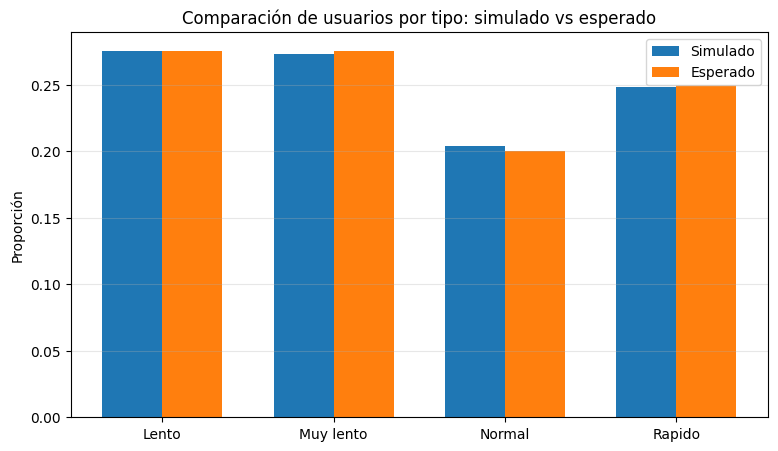

In [26]:
comparacion_grafica = comparacion_usuarios_tipo.copy()
comparacion_grafica = comparacion_grafica.sort_values("tipo_usuario")

x = np.arange(len(comparacion_grafica))
ancho = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - ancho/2,
    comparacion_grafica["porcentaje_simulado"],
    width=ancho,
    label="Simulado"
)

plt.bar(
    x + ancho/2,
    comparacion_grafica["porcentaje_esperado"],
    width=ancho,
    label="Esperado"
)

plt.xticks(x, comparacion_grafica["tipo_usuario"])
plt.ylabel("Proporción")
plt.title("Comparación de usuarios por tipo: simulado vs esperado")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

La comparación entre los porcentajes simulados y los porcentajes esperados permite validar que la generación de usuarios está funcionando de forma coherente. Aunque los valores no son exactamente iguales por el efecto aleatorio de la simulación, las proporciones se mantienen cercanas a las definidas en el problema.

In [27]:
comparacion_usuarios_tipo[[
    "tipo_usuario",
    "porcentaje_simulado",
    "porcentaje_esperado",
    "diferencia"
]].round(4)

,tipo_usuario,porcentaje_simulado,porcentaje_esperado,diferencia
0,Lento,0.2755,0.275,0.0005
1,Muy lento,0.2728,0.275,-0.0022
2,Normal,0.2038,0.200,0.0038
3,Rapido,0.2479,0.250,-0.0021


Los porcentajes simulados son muy cercanos a los porcentajes esperados del enunciado. Esto indica que la asignación aleatoria de tipos de usuario está funcionando correctamente y que la simulación respeta la distribución definida para rápidos, normales, lentos y muy lentos.

In [28]:
orden_tipos = ["Rapido", "Normal", "Lento", "Muy lento"]

comparacion_usuarios_tipo["tipo_usuario"] = pd.Categorical(
    comparacion_usuarios_tipo["tipo_usuario"],
    categories=orden_tipos,
    ordered=True
)

comparacion_usuarios_tipo = comparacion_usuarios_tipo.sort_values("tipo_usuario")

comparacion_usuarios_tipo[[
    "tipo_usuario",
    "porcentaje_simulado",
    "porcentaje_esperado",
    "diferencia"
]].round(4)

,tipo_usuario,porcentaje_simulado,porcentaje_esperado,diferencia
3,Rapido,0.2479,0.250,-0.0021
2,Normal,0.2038,0.200,0.0038
0,Lento,0.2755,0.275,0.0005
1,Muy lento,0.2728,0.275,-0.0022


## Estado estable y eliminación del estado transitorio

En una simulación, los primeros resultados pueden estar afectados por el arranque del sistema. A ese periodo inicial se le conoce como estado transitorio o periodo de calentamiento.

Para evitar que ese tramo inicial afecte el análisis final, se revisa el comportamiento del tiempo promedio en sistema por réplica. Luego se usa un promedio móvil para identificar desde qué punto los valores se estabilizan y se recalculan las estadísticas usando solo las réplicas posteriores a ese punto.

In [29]:
metricas_replica = (
    df_resultados
    .groupby("replica")
    .agg(
        usuarios=("usuario_id", "count"),
        tiempo_servicio_promedio=("tiempo_servicio", "mean"),
        tiempo_espera_promedio=("tiempo_espera", "mean"),
        tiempo_sistema_promedio=("tiempo_sistema", "mean"),
        espera_p95=("tiempo_espera", lambda x: np.percentile(x, 95)),
        sistema_p95=("tiempo_sistema", lambda x: np.percentile(x, 95))
    )
    .reset_index()
)

metricas_replica.head()

,replica,usuarios,tiempo_servicio_promedio,tiempo_espera_promedio,tiempo_sistema_promedio,espera_p95,sistema_p95
0,1,224,3.381473,1.475182,4.856656,8.941343,16.523026
1,2,224,3.650705,1.398877,5.049582,10.147346,16.645168
2,3,206,3.401552,1.505238,4.906790,10.657855,16.504873
3,4,226,3.703358,1.790582,5.493940,12.557161,16.712512
4,5,223,3.387182,1.115302,4.502484,7.286981,11.566119


In [30]:
metricas_replica["promedio_acumulado_sistema"] = (
    metricas_replica["tiempo_sistema_promedio"]
    .expanding()
    .mean()
)

metricas_replica["promedio_movil_sistema"] = (
    metricas_replica["tiempo_sistema_promedio"]
    .rolling(window=10, min_periods=1)
    .mean()
)

metricas_replica[
    [
        "replica",
        "tiempo_sistema_promedio",
        "promedio_acumulado_sistema",
        "promedio_movil_sistema"
    ]
].head(15).round(3)

,replica,tiempo_sistema_promedio,promedio_acumulado_sistema,promedio_movil_sistema
0,1,4.857,4.857,4.857
1,2,5.050,4.953,4.953
2,3,4.907,4.938,4.938
3,4,5.494,5.077,5.077
4,5,4.502,4.962,4.962
5,6,4.582,4.899,4.899
6,7,6.087,5.068,5.068
7,8,5.497,5.122,5.122
8,9,6.169,5.238,5.238
9,10,5.072,5.222,5.222


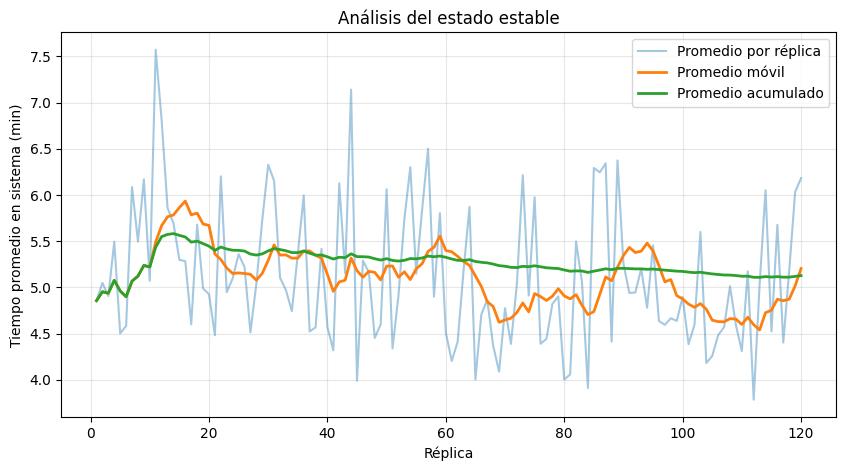

In [31]:
plt.figure(figsize=(10, 5))

plt.plot(
    metricas_replica["replica"],
    metricas_replica["tiempo_sistema_promedio"],
    alpha=0.4,
    label="Promedio por réplica"
)

plt.plot(
    metricas_replica["replica"],
    metricas_replica["promedio_movil_sistema"],
    linewidth=2,
    label="Promedio móvil"
)

plt.plot(
    metricas_replica["replica"],
    metricas_replica["promedio_acumulado_sistema"],
    linewidth=2,
    label="Promedio acumulado"
)

plt.title("Análisis del estado estable")
plt.xlabel("Réplica")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [32]:
porcentaje_transitorio = 0.10

punto_corte = int(NUM_REPLICAS * porcentaje_transitorio)

print("Réplicas totales:", NUM_REPLICAS)
print("Réplicas eliminadas como transitorio:", punto_corte)
print("Primera réplica usada para estado estable:", punto_corte + 1)

Réplicas totales: 120
Réplicas eliminadas como transitorio: 12
Primera réplica usada para estado estable: 13


In [33]:
df_estable = df_resultados[df_resultados["replica"] > punto_corte].copy()

print("Usuarios antes de eliminar transitorio:", len(df_resultados))
print("Usuarios después de eliminar transitorio:", len(df_estable))
print("Réplicas usadas después del corte:", df_estable["replica"].nunique())

Usuarios antes de eliminar transitorio: 25952
Usuarios después de eliminar transitorio: 23395
Réplicas usadas después del corte: 108


In [34]:
comparacion_transitorio = pd.DataFrame({
    "Etapa": ["Con transitorio", "Sin transitorio"],
    "Tiempo promedio de servicio": [
        df_resultados["tiempo_servicio"].mean(),
        df_estable["tiempo_servicio"].mean()
    ],
    "Tiempo promedio de espera": [
        df_resultados["tiempo_espera"].mean(),
        df_estable["tiempo_espera"].mean()
    ],
    "Tiempo promedio en sistema": [
        df_resultados["tiempo_sistema"].mean(),
        df_estable["tiempo_sistema"].mean()
    ]
})

comparacion_transitorio.round(3)

,Etapa,Tiempo promedio de servicio,Tiempo promedio de espera,Tiempo promedio en sistema
0,Con transitorio,3.557,1.564,5.121
1,Sin transitorio,3.540,1.534,5.074


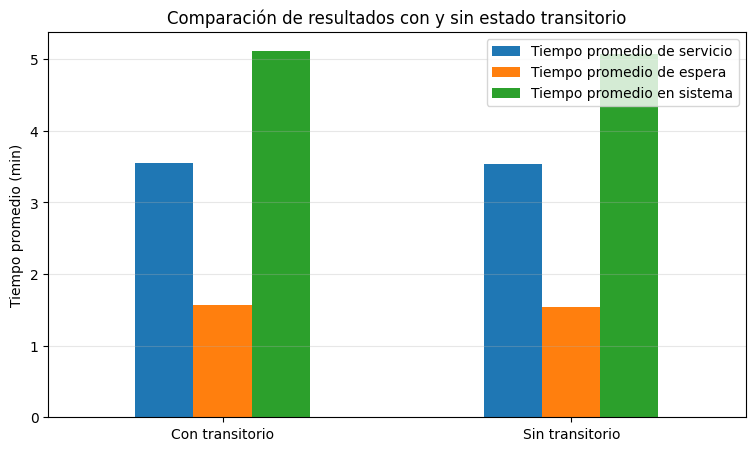

In [35]:
comparacion_grafica = comparacion_transitorio.set_index("Etapa")

comparacion_grafica.plot(kind="bar", figsize=(9, 5))

plt.title("Comparación de resultados con y sin estado transitorio")
plt.ylabel("Tiempo promedio (min)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

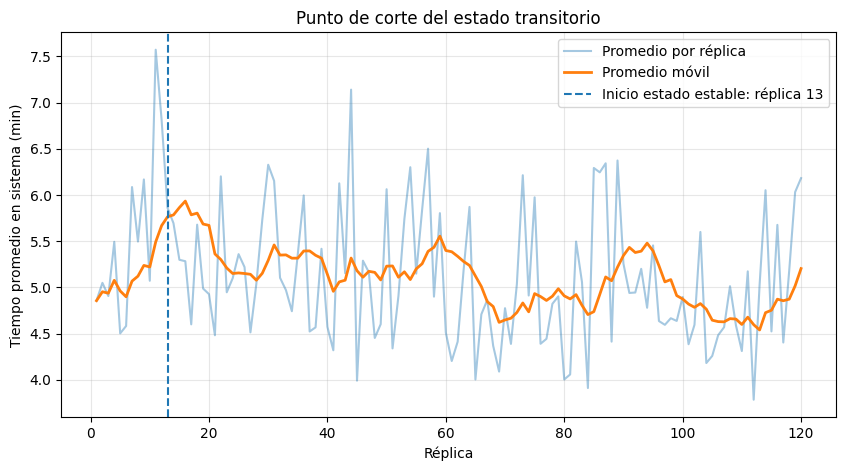

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(
    metricas_replica["replica"],
    metricas_replica["tiempo_sistema_promedio"],
    alpha=0.4,
    label="Promedio por réplica"
)

plt.plot(
    metricas_replica["replica"],
    metricas_replica["promedio_movil_sistema"],
    linewidth=2,
    label="Promedio móvil"
)

plt.axvline(
    x=punto_corte + 1,
    linestyle="--",
    label=f"Inicio estado estable: réplica {punto_corte + 1}"
)

plt.title("Punto de corte del estado transitorio")
plt.xlabel("Réplica")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Después de analizar el comportamiento del tiempo promedio en sistema, se elimina el 10% inicial de las réplicas como periodo transitorio. Con esto se busca reducir el efecto del arranque de la simulación y trabajar con datos más representativos del comportamiento estable del sistema.

La comparación antes y después muestra si la eliminación del transitorio cambia de forma importante los tiempos promedio. A partir de este punto, las estadísticas finales se calculan usando el conjunto de datos sin transitorio.

## Estadísticas finales sin estado transitorio

Después de eliminar las primeras réplicas consideradas como periodo transitorio, se recalculan las estadísticas principales del sistema. Esto permite trabajar con datos más representativos del comportamiento estable de la simulación.

En esta sección se actualizan las estadísticas por cajero, los promedios por tipo de usuario y las métricas generales que servirán como base para las conclusiones del trabajo.

In [37]:
resumen_cajeros_estable = resumen_por_cajero(df_estable)

resumen_cajeros_estable.round(3)

,cajero,usuarios_atendidos,tiempo_servicio_media,tiempo_servicio_desviacion,tiempo_servicio_min,tiempo_servicio_max,tiempo_servicio_ic95_inf,tiempo_servicio_ic95_sup,tiempo_espera_media,tiempo_espera_desviacion,tiempo_espera_min,tiempo_espera_max,tiempo_espera_ic95_inf,tiempo_espera_ic95_sup,tiempo_sistema_media,tiempo_sistema_desviacion,tiempo_sistema_min,tiempo_sistema_max,tiempo_sistema_ic95_inf,tiempo_sistema_ic95_sup
0,1,7694,3.528,4.443,0.000,61.252,3.429,3.627,1.453,4.162,0.0,48.706,1.360,1.546,4.981,6.044,0.000,69.815,4.846,5.116
1,2,7898,3.539,4.360,0.001,47.398,3.443,3.635,1.554,4.108,0.0,41.125,1.463,1.645,5.093,5.875,0.002,49.665,4.963,5.223
2,3,7803,3.552,4.378,0.000,44.812,3.455,3.649,1.595,4.127,0.0,43.613,1.503,1.686,5.146,5.953,0.000,52.563,5.014,5.278


In [38]:
resumen_cajeros_estable_simple = resumen_cajeros_estable[
    [
        "cajero",
        "usuarios_atendidos",
        "tiempo_servicio_media",
        "tiempo_espera_media",
        "tiempo_sistema_media",
        "tiempo_sistema_ic95_inf",
        "tiempo_sistema_ic95_sup"
    ]
].copy()

resumen_cajeros_estable_simple.round(3)

,cajero,usuarios_atendidos,tiempo_servicio_media,tiempo_espera_media,tiempo_sistema_media,tiempo_sistema_ic95_inf,tiempo_sistema_ic95_sup
0,1,7694,3.528,1.453,4.981,4.846,5.116
1,2,7898,3.539,1.554,5.093,4.963,5.223
2,3,7803,3.552,1.595,5.146,5.014,5.278


In [39]:
cajero_menor_estable = resumen_cajeros_estable_simple.loc[
    resumen_cajeros_estable_simple["tiempo_sistema_media"].idxmin()
]

cajero_mayor_estable = resumen_cajeros_estable_simple.loc[
    resumen_cajeros_estable_simple["tiempo_sistema_media"].idxmax()
]

print("Cajero con menor tiempo promedio en sistema:")
print(cajero_menor_estable[["cajero", "tiempo_sistema_media"]])

print("\nCajero con mayor tiempo promedio en sistema:")
print(cajero_mayor_estable[["cajero", "tiempo_sistema_media"]])

Cajero con menor tiempo promedio en sistema:
cajero                  1.000000
tiempo_sistema_media    4.981163
Name: 0, dtype: float64

Cajero con mayor tiempo promedio en sistema:
cajero                  3.000000
tiempo_sistema_media    5.146326
Name: 2, dtype: float64


In [40]:
usuarios_por_tipo_replica_estable = (
    df_estable
    .groupby(["replica", "tipo_usuario"])
    .size()
    .unstack(fill_value=0)
)

promedio_usuarios_tipo_estable = (
    usuarios_por_tipo_replica_estable
    .mean()
    .reset_index()
)

promedio_usuarios_tipo_estable.columns = [
    "tipo_usuario",
    "promedio_usuarios_por_replica"
]

promedio_usuarios_tipo_estable.round(2)

,tipo_usuario,promedio_usuarios_por_replica
0,Lento,59.22
1,Muy lento,59.38
2,Normal,44.32
3,Rapido,53.69


In [41]:
porcentaje_simulado_estable = (
    df_estable["tipo_usuario"]
    .value_counts(normalize=True)
    .rename_axis("tipo_usuario")
    .reset_index(name="porcentaje_simulado")
)

porcentaje_esperado = pd.DataFrame([
    {
        "tipo_usuario": tipo,
        "porcentaje_esperado": datos["probabilidad"]
    }
    for tipo, datos in usuarios.items()
])

comparacion_usuarios_tipo_estable = (
    promedio_usuarios_tipo_estable
    .merge(porcentaje_simulado_estable, on="tipo_usuario")
    .merge(porcentaje_esperado, on="tipo_usuario")
)

comparacion_usuarios_tipo_estable["diferencia"] = (
    comparacion_usuarios_tipo_estable["porcentaje_simulado"]
    - comparacion_usuarios_tipo_estable["porcentaje_esperado"]
)

orden_tipos = ["Rapido", "Normal", "Lento", "Muy lento"]

comparacion_usuarios_tipo_estable["tipo_usuario"] = pd.Categorical(
    comparacion_usuarios_tipo_estable["tipo_usuario"],
    categories=orden_tipos,
    ordered=True
)

comparacion_usuarios_tipo_estable = (
    comparacion_usuarios_tipo_estable
    .sort_values("tipo_usuario")
)

comparacion_usuarios_tipo_estable.round(4)

,tipo_usuario,promedio_usuarios_por_replica,porcentaje_simulado,porcentaje_esperado,diferencia
3,Rapido,53.6944,0.2479,0.250,-0.0021
2,Normal,44.3241,0.2046,0.200,0.0046
0,Lento,59.2222,0.2734,0.275,-0.0016
1,Muy lento,59.3796,0.2741,0.275,-0.0009


In [42]:
metricas_generales_estables = pd.DataFrame({
    "Métrica": [
        "Usuarios simulados después del transitorio",
        "Réplicas usadas después del transitorio",
        "Tiempo promedio de servicio",
        "Tiempo promedio de espera Wq",
        "Tiempo promedio en sistema W",
        "Percentil 95 de espera",
        "Percentil 95 en sistema"
    ],
    "Valor": [
        len(df_estable),
        df_estable["replica"].nunique(),
        df_estable["tiempo_servicio"].mean(),
        df_estable["tiempo_espera"].mean(),
        df_estable["tiempo_sistema"].mean(),
        np.percentile(df_estable["tiempo_espera"], 95),
        np.percentile(df_estable["tiempo_sistema"], 95)
    ]
})

metricas_generales_estables.round(3)

,Métrica,Valor
0,Usuarios simulados después del transitorio,23395.000
1,Réplicas usadas después del transitorio,108.000
2,Tiempo promedio de servicio,3.540
3,Tiempo promedio de espera Wq,1.534
4,Tiempo promedio en sistema W,5.074
5,Percentil 95 de espera,9.562
6,Percentil 95 en sistema,16.617


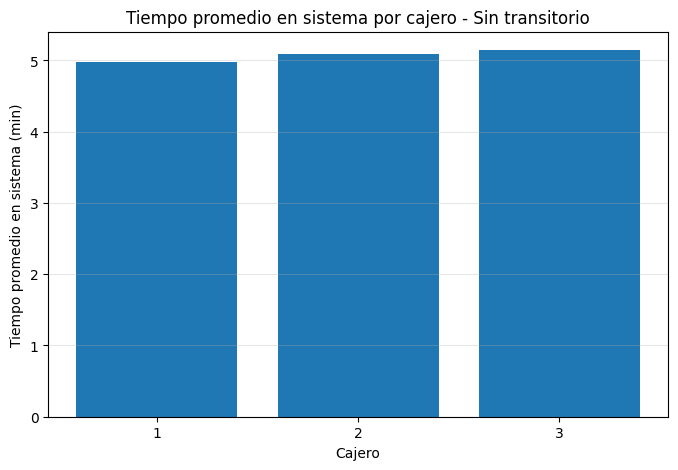

In [43]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_cajeros_estable_simple["cajero"].astype(str),
    resumen_cajeros_estable_simple["tiempo_sistema_media"]
)

plt.title("Tiempo promedio en sistema por cajero - Sin transitorio")
plt.xlabel("Cajero")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.grid(axis="y", alpha=0.3)

plt.show()

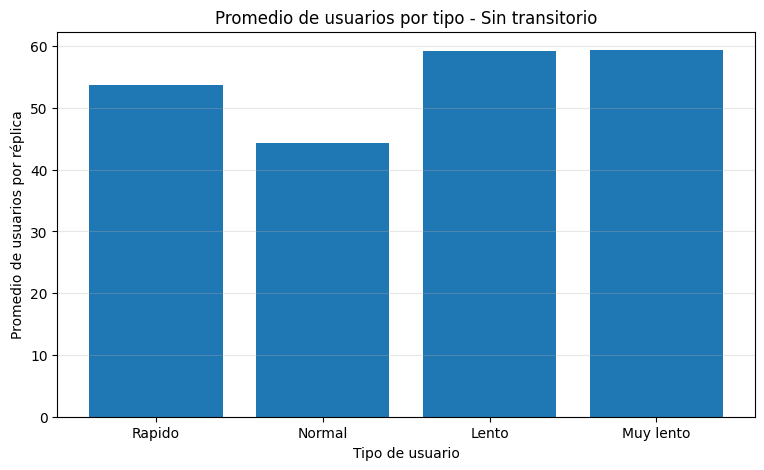

In [44]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparacion_usuarios_tipo_estable["tipo_usuario"].astype(str),
    comparacion_usuarios_tipo_estable["promedio_usuarios_por_replica"]
)

plt.title("Promedio de usuarios por tipo - Sin transitorio")
plt.xlabel("Tipo de usuario")
plt.ylabel("Promedio de usuarios por réplica")
plt.grid(axis="y", alpha=0.3)

plt.show()

Al recalcular las estadísticas sin el estado transitorio, se obtiene una base más adecuada para interpretar el funcionamiento del sistema. Estos resultados permiten identificar el cajero con mejor y peor desempeño, revisar la distribución de usuarios y evaluar si los tiempos promedio cumplen con los criterios definidos para el servicio.

## Criterio de decisión

Para decidir si los tres cajeros son suficientes, se comparan los resultados de la simulación con los criterios sugeridos en el documento del laboratorio.

Se revisan principalmente el tiempo promedio de espera en cola, el tiempo promedio total en el sistema y los valores altos de espera representados mediante el percentil 95. Con esta comparación se busca establecer si el sistema funciona de manera aceptable o si requiere una estrategia de mejora.

In [45]:
criterios_decision = {
    "Wq aceptable": 3,
    "Wq crítico": 5,
    "W aceptable": 5,
    "W crítico": 8,
    "Percentil 95 espera referencia": 5
}

In [46]:
Wq = df_estable["tiempo_espera"].mean()
W = df_estable["tiempo_sistema"].mean()
p95_espera = np.percentile(df_estable["tiempo_espera"], 95)
p95_sistema = np.percentile(df_estable["tiempo_sistema"], 95)

tabla_decision = pd.DataFrame([
    {
        "Métrica": "Tiempo promedio de espera Wq",
        "Resultado": Wq,
        "Criterio aceptable": criterios_decision["Wq aceptable"],
        "Criterio crítico": criterios_decision["Wq crítico"],
        "Estado": "Aceptable" if Wq <= criterios_decision["Wq aceptable"] else "Alerta" if Wq <= criterios_decision["Wq crítico"] else "Crítico"
    },
    {
        "Métrica": "Tiempo promedio en sistema W",
        "Resultado": W,
        "Criterio aceptable": criterios_decision["W aceptable"],
        "Criterio crítico": criterios_decision["W crítico"],
        "Estado": "Aceptable" if W <= criterios_decision["W aceptable"] else "Alerta" if W <= criterios_decision["W crítico"] else "Crítico"
    },
    {
        "Métrica": "Percentil 95 de espera",
        "Resultado": p95_espera,
        "Criterio aceptable": criterios_decision["Percentil 95 espera referencia"],
        "Criterio crítico": "No definido",
        "Estado": "Alerta" if p95_espera > criterios_decision["Percentil 95 espera referencia"] else "Aceptable"
    },
    {
        "Métrica": "Percentil 95 en sistema",
        "Resultado": p95_sistema,
        "Criterio aceptable": "Referencia complementaria",
        "Criterio crítico": "No definido",
        "Estado": "Informativo"
    }
])

tabla_decision.round(3)

,Métrica,Resultado,Criterio aceptable,Criterio crítico,Estado
0,Tiempo promedio de espera Wq,1.534,3,5,Aceptable
1,Tiempo promedio en sistema W,5.074,5,8,Alerta
2,Percentil 95 de espera,9.562,5,No definido,Alerta
3,Percentil 95 en sistema,16.617,Referencia complementaria,No definido,Informativo


In [47]:
if Wq <= criterios_decision["Wq aceptable"] and W <= criterios_decision["W aceptable"]:
    decision_final = "Los tres cajeros son suficientes bajo los criterios promedio definidos."
elif Wq <= criterios_decision["Wq crítico"] and W <= criterios_decision["W crítico"]:
    decision_final = (
        "Los tres cajeros permiten operar el sistema, pero se recomienda una mejora preventiva "
        "porque al menos una métrica se encuentra en zona de alerta."
    )
else:
    decision_final = (
        "Los tres cajeros no son suficientes bajo los criterios definidos. "
        "Se recomienda agregar capacidad al sistema."
    )

print(decision_final)

Los tres cajeros permiten operar el sistema, pero se recomienda una mejora preventiva porque al menos una métrica se encuentra en zona de alerta.


Los tres cajeros permiten operar el sistema, pero se recomienda una mejora preventiva porque al menos una métrica se encuentra en zona de alerta.

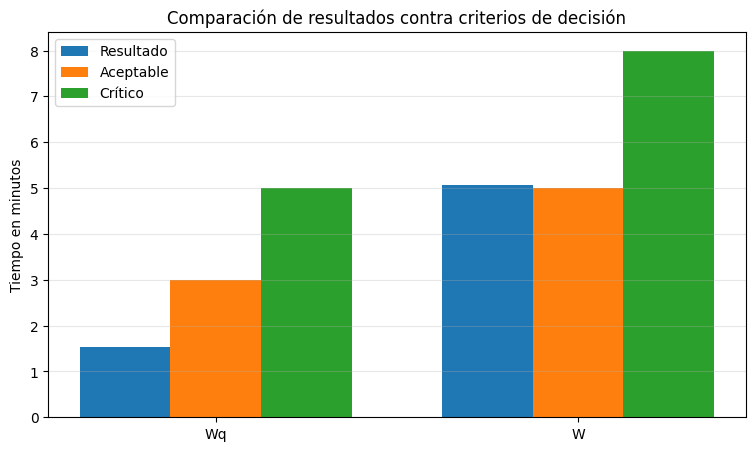

In [48]:
metricas_comparar = pd.DataFrame({
    "Métrica": ["Wq", "W"],
    "Resultado": [Wq, W],
    "Aceptable": [
        criterios_decision["Wq aceptable"],
        criterios_decision["W aceptable"]
    ],
    "Crítico": [
        criterios_decision["Wq crítico"],
        criterios_decision["W crítico"]
    ]
})

x = np.arange(len(metricas_comparar))
ancho = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - ancho, metricas_comparar["Resultado"], width=ancho, label="Resultado")
plt.bar(x, metricas_comparar["Aceptable"], width=ancho, label="Aceptable")
plt.bar(x + ancho, metricas_comparar["Crítico"], width=ancho, label="Crítico")

plt.xticks(x, metricas_comparar["Métrica"])
plt.ylabel("Tiempo en minutos")
plt.title("Comparación de resultados contra criterios de decisión")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

La comparación contra los criterios de decisión muestra que el tiempo promedio de espera en cola se mantiene dentro del rango aceptable. Sin embargo, el tiempo promedio total en el sistema supera ligeramente el valor aceptable definido, aunque se mantiene por debajo del nivel crítico.

Por esta razón, se considera que los tres cajeros permiten operar el sistema, pero se recomienda implementar una mejora preventiva para reducir los tiempos altos, especialmente en usuarios lentos y muy lentos.

Como estrategia de mejora se recomienda mantener los tres cajeros actuales, pero implementar una fila o cajero de apoyo en horarios de alta demanda, especialmente para usuarios lentos o muy lentos. Otra alternativa es mejorar la interfaz del cajero para reducir el tiempo de interacción de estos usuarios, por ejemplo mediante instrucciones más claras, lectura automática de placa o asistencia visual durante el proceso de pago.

No se recomienda agregar un cajero permanente de forma inmediata, porque el tiempo promedio de espera se mantiene dentro del rango aceptable. Sin embargo, sí se recomienda una mejora preventiva, ya que el tiempo promedio total en sistema supera ligeramente el criterio aceptable y el percentil 95 muestra esperas elevadas para algunos usuarios.

## Verificación, calibración y validación del modelo

En esta etapa se revisa la calidad del modelo construido. La verificación permite comprobar que el código funciona correctamente, la calibración confirma que los parámetros usados corresponden a los datos del problema y la validación permite revisar si los resultados obtenidos son coherentes con la teoría del modelo M/M/1 y con el comportamiento esperado del sistema.

### Verificación

La verificación busca responder si el modelo fue construido correctamente. Para esto se revisan aspectos básicos del código y de los datos generados: existencia de tiempos negativos, uso de los tres cajeros, generación de los cuatro tipos de usuarios y consistencia entre los tiempos de llegada, inicio de atención y finalización.

In [49]:
verificacion = []

# 1. Verificar tiempos negativos
tiempos_negativos = (df_resultados[columnas_tiempo] < 0).sum().sum()

verificacion.append({
    "Prueba": "No existen tiempos negativos",
    "Resultado": "Cumple" if tiempos_negativos == 0 else "No cumple",
    "Detalle": f"Tiempos negativos encontrados: {tiempos_negativos}"
})

# 2. Verificar uso de los tres cajeros
cajeros_usados = sorted(df_resultados["cajero"].unique())
verificacion.append({
    "Prueba": "Se utilizan los tres cajeros",
    "Resultado": "Cumple" if cajeros_usados == [1, 2, 3] else "No cumple",
    "Detalle": f"Cajeros usados: {cajeros_usados}"
})

# 3. Verificar generación de los cuatro tipos de usuario
tipos_generados = sorted(df_resultados["tipo_usuario"].unique())
tipos_esperados = sorted(list(usuarios.keys()))

verificacion.append({
    "Prueba": "Se generan los cuatro tipos de usuario",
    "Resultado": "Cumple" if tipos_generados == tipos_esperados else "No cumple",
    "Detalle": f"Tipos generados: {tipos_generados}"
})

# 4. Verificar que el inicio de atención no sea antes de la llegada
errores_inicio = (df_resultados["inicio_atencion"] < df_resultados["tiempo_llegada"]).sum()

verificacion.append({
    "Prueba": "El inicio de atención ocurre después de la llegada",
    "Resultado": "Cumple" if errores_inicio == 0 else "No cumple",
    "Detalle": f"Registros con error: {errores_inicio}"
})

# 5. Verificar que el fin de atención sea posterior al inicio
errores_fin = (df_resultados["fin_atencion"] < df_resultados["inicio_atencion"]).sum()

verificacion.append({
    "Prueba": "El fin de atención ocurre después del inicio",
    "Resultado": "Cumple" if errores_fin == 0 else "No cumple",
    "Detalle": f"Registros con error: {errores_fin}"
})

tabla_verificacion = pd.DataFrame(verificacion)

tabla_verificacion

,Prueba,Resultado,Detalle
0,No existen tiempos negativos,Cumple,Tiempos negativos encontrados: 0
1,Se utilizan los tres cajeros,Cumple,"Cajeros usados: [np.int64(1), np.int64(2), np...."
2,Se generan los cuatro tipos de usuario,Cumple,"Tipos generados: [np.str_('Lento'), np.str_('M..."
3,El inicio de atención ocurre después de la lle...,Cumple,Registros con error: 0
4,El fin de atención ocurre después del inicio,Cumple,Registros con error: 0


### Calibración

La calibración consiste en revisar que el modelo use correctamente los parámetros definidos en el problema. En este caso se verifican las medias de llegada, las medias de servicio y las probabilidades de cada tipo de usuario. También se comparan los porcentajes simulados contra los porcentajes esperados.

In [50]:
tabla_calibracion = tabla_parametros.copy()

tabla_calibracion["Probabilidad (%)"] = tabla_calibracion["Probabilidad"] * 100
tabla_calibracion["Lambda λ"] = tabla_calibracion["Lambda λ"].round(3)
tabla_calibracion["Mu μ"] = tabla_calibracion["Mu μ"].round(3)
tabla_calibracion["Rho ρ"] = tabla_calibracion["Rho ρ"].round(3)

tabla_calibracion[
    [
        "Tipo de usuario",
        "Media servicio (min)",
        "Media llegada (min)",
        "Probabilidad (%)",
        "Lambda λ",
        "Mu μ",
        "Rho ρ"
    ]
]

,Tipo de usuario,Media servicio (min),Media llegada (min),Probabilidad (%),Lambda λ,Mu μ,Rho ρ
0,Rapido,1.0,3.0,25.0,0.333,1.000,0.333
1,Normal,3.0,3.0,20.0,0.333,0.333,1.000
2,Lento,4.0,5.0,27.5,0.200,0.250,0.800
3,Muy lento,6.0,7.0,27.5,0.143,0.167,0.857


In [51]:
calibracion_probabilidades = comparacion_usuarios_tipo_estable[
    [
        "tipo_usuario",
        "porcentaje_simulado",
        "porcentaje_esperado",
        "diferencia"
    ]
].copy()

calibracion_probabilidades.round(4)

,tipo_usuario,porcentaje_simulado,porcentaje_esperado,diferencia
3,Rapido,0.2479,0.250,-0.0021
2,Normal,0.2046,0.200,0.0046
0,Lento,0.2734,0.275,-0.0016
1,Muy lento,0.2741,0.275,-0.0009


### Validación

La validación busca revisar si el modelo representa de forma razonable el sistema planteado. Para esto se comparan los resultados simulados con aspectos esperados de la teoría M/M/1: llegadas exponenciales, servicios exponenciales, filas independientes y comportamiento estable cuando el factor de utilización es menor que 1.

Además, se revisa si los resultados globales son coherentes con los criterios definidos para el sistema de parqueaderos.

In [52]:
tabla_decision.round(3)

,Métrica,Resultado,Criterio aceptable,Criterio crítico,Estado
0,Tiempo promedio de espera Wq,1.534,3,5,Aceptable
1,Tiempo promedio en sistema W,5.074,5,8,Alerta
2,Percentil 95 de espera,9.562,5,No definido,Alerta
3,Percentil 95 en sistema,16.617,Referencia complementaria,No definido,Informativo


In [53]:
validacion = []

# Validación 1: Wq dentro de rango aceptable
validacion.append({
    "Aspecto evaluado": "Tiempo promedio de espera Wq",
    "Resultado obtenido": round(Wq, 3),
    "Referencia": "Aceptable si Wq <= 3 min",
    "Conclusión": "Coherente" if Wq <= 3 else "Revisar"
})

# Validación 2: W frente al criterio aceptable
validacion.append({
    "Aspecto evaluado": "Tiempo promedio en sistema W",
    "Resultado obtenido": round(W, 3),
    "Referencia": "Aceptable si W <= 5 min; crítico si W > 8 min",
    "Conclusión": "Aceptable" if W <= 5 else "Zona de alerta" if W <= 8 else "Crítico"
})

# Validación 3: distribución de usuarios
max_diferencia = comparacion_usuarios_tipo_estable["diferencia"].abs().max()

validacion.append({
    "Aspecto evaluado": "Distribución de usuarios",
    "Resultado obtenido": round(max_diferencia, 4),
    "Referencia": "Diferencias pequeñas frente a porcentajes esperados",
    "Conclusión": "Coherente" if max_diferencia < 0.01 else "Revisar"
})

# Validación 4: consistencia entre espera, servicio y sistema
diferencia_tiempos = abs(
    df_estable["tiempo_sistema"].mean()
    - (df_estable["tiempo_espera"].mean() + df_estable["tiempo_servicio"].mean())
)

validacion.append({
    "Aspecto evaluado": "Consistencia W = Wq + servicio",
    "Resultado obtenido": round(diferencia_tiempos, 6),
    "Referencia": "La diferencia debe ser cercana a 0",
    "Conclusión": "Coherente" if diferencia_tiempos < 0.001 else "Revisar"
})

tabla_validacion = pd.DataFrame(validacion)

tabla_validacion

,Aspecto evaluado,Resultado obtenido,Referencia,Conclusión
0,Tiempo promedio de espera Wq,1.5340,Aceptable si Wq <= 3 min,Coherente
1,Tiempo promedio en sistema W,5.0740,Aceptable si W <= 5 min; crítico si W > 8 min,Zona de alerta
2,Distribución de usuarios,0.0046,Diferencias pequeñas frente a porcentajes espe...,Coherente
3,Consistencia W = Wq + servicio,0.0000,La diferencia debe ser cercana a 0,Coherente


### Diagrama del proceso de verificación, calibración y validación

El siguiente diagrama resume el proceso aplicado para revisar el modelo. Primero se verifica que la simulación funcione correctamente, luego se calibran los parámetros con los datos entregados y finalmente se validan los resultados frente a la teoría y los criterios de decisión.

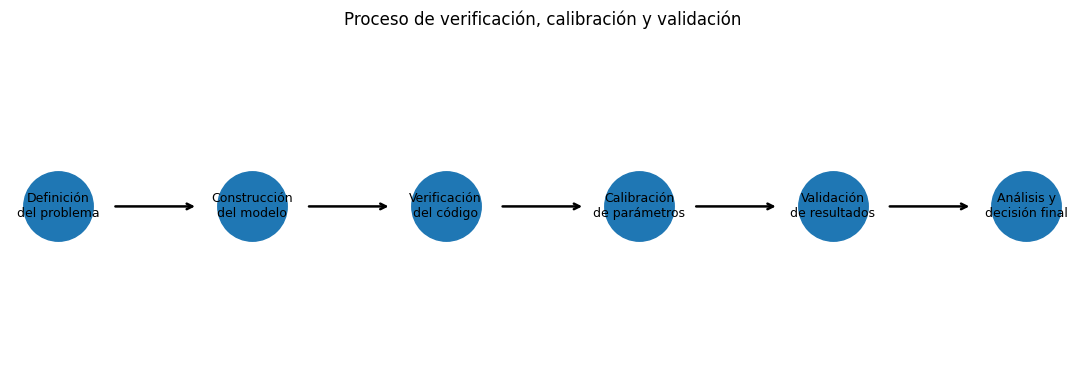

In [54]:
plt.figure(figsize=(11, 4))

pasos = [
    "Definición\ndel problema",
    "Construcción\ndel modelo",
    "Verificación\ndel código",
    "Calibración\nde parámetros",
    "Validación\nde resultados",
    "Análisis y\ndecisión final"
]

x = np.arange(len(pasos))
y = np.ones(len(pasos))

plt.scatter(x, y, s=2500)

for i, paso in enumerate(pasos):
    plt.text(
        x[i],
        y[i],
        paso,
        ha="center",
        va="center",
        fontsize=9
    )

for i in range(len(pasos) - 1):
    plt.annotate(
        "",
        xy=(x[i + 1] - 0.28, y[i]),
        xytext=(x[i] + 0.28, y[i]),
        arrowprops=dict(arrowstyle="->", lw=1.8)
    )

plt.title("Proceso de verificación, calibración y validación")
plt.axis("off")
plt.tight_layout()
plt.show()

Las pruebas realizadas muestran que el modelo cumple con las condiciones básicas de funcionamiento: no genera tiempos negativos, utiliza los tres cajeros, produce los cuatro tipos de usuarios y mantiene coherencia entre los tiempos calculados.

La calibración confirma que los parámetros usados corresponden a los datos del laboratorio. Finalmente, la validación muestra que los resultados son consistentes con el comportamiento esperado del sistema, aunque el tiempo promedio en sistema queda en zona de alerta, lo cual justifica proponer una mejora preventiva.

## Exportación de resultados

En esta etapa se exportan las tablas y gráficas principales de la simulación. Esto facilita la construcción del documento final, ya que los resultados quedan organizados en archivos separados y pueden insertarse directamente en Word.

Se exportan las tablas de parámetros, estadísticas por cajero, usuarios por tipo, criterios de decisión, verificación, calibración y validación. También se guardan las gráficas generadas durante el análisis.

In [55]:
import os

carpeta_salida = "resultados_parqueadero"
carpeta_graficas = os.path.join(carpeta_salida, "graficas")

os.makedirs(carpeta_salida, exist_ok=True)
os.makedirs(carpeta_graficas, exist_ok=True)

print("Carpetas creadas correctamente.")

Carpetas creadas correctamente.


In [56]:
ruta_excel = os.path.join(carpeta_salida, "tablas_resultados_parqueadero.xlsx")

with pd.ExcelWriter(ruta_excel, engine="openpyxl") as writer:
    tabla_parametros.round(4).to_excel(
        writer,
        sheet_name="Parametros",
        index=False
    )

    resumen_cajeros_estable_simple.round(4).to_excel(
        writer,
        sheet_name="Cajeros",
        index=False
    )

    comparacion_usuarios_tipo_estable.round(4).to_excel(
        writer,
        sheet_name="Usuarios_tipo",
        index=False
    )

    metricas_generales_estables.round(4).to_excel(
        writer,
        sheet_name="Metricas_generales",
        index=False
    )

    tabla_decision.round(4).to_excel(
        writer,
        sheet_name="Decision",
        index=False
    )

    tabla_verificacion.to_excel(
        writer,
        sheet_name="Verificacion",
        index=False
    )

    tabla_calibracion.round(4).to_excel(
        writer,
        sheet_name="Calibracion",
        index=False
    )

    tabla_validacion.to_excel(
        writer,
        sheet_name="Validacion",
        index=False
    )

    comparacion_transitorio.round(4).to_excel(
        writer,
        sheet_name="Transitorio",
        index=False
    )

print("Archivo Excel exportado en:", ruta_excel)

Archivo Excel exportado en: resultados_parqueadero/tablas_resultados_parqueadero.xlsx


In [57]:
tabla_parametros.round(4).to_csv(
    os.path.join(carpeta_salida, "tabla_parametros.csv"),
    index=False
)

resumen_cajeros_estable_simple.round(4).to_csv(
    os.path.join(carpeta_salida, "tabla_cajeros.csv"),
    index=False
)

comparacion_usuarios_tipo_estable.round(4).to_csv(
    os.path.join(carpeta_salida, "tabla_usuarios_tipo.csv"),
    index=False
)

metricas_generales_estables.round(4).to_csv(
    os.path.join(carpeta_salida, "tabla_metricas_generales.csv"),
    index=False
)

tabla_decision.round(4).to_csv(
    os.path.join(carpeta_salida, "tabla_decision.csv"),
    index=False
)

tabla_verificacion.to_csv(
    os.path.join(carpeta_salida, "tabla_verificacion.csv"),
    index=False
)

tabla_validacion.to_csv(
    os.path.join(carpeta_salida, "tabla_validacion.csv"),
    index=False
)

print("Tablas CSV exportadas correctamente.")

Tablas CSV exportadas correctamente.


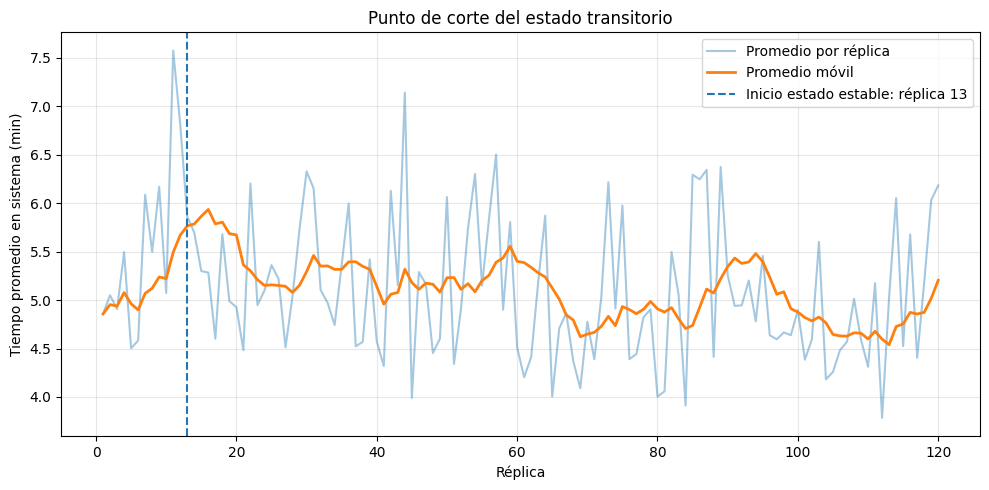

Gráfica guardada en: resultados_parqueadero/graficas/estado_estable_transitorio.png


In [58]:
plt.figure(figsize=(10, 5))

plt.plot(
    metricas_replica["replica"],
    metricas_replica["tiempo_sistema_promedio"],
    alpha=0.4,
    label="Promedio por réplica"
)

plt.plot(
    metricas_replica["replica"],
    metricas_replica["promedio_movil_sistema"],
    linewidth=2,
    label="Promedio móvil"
)

plt.axvline(
    x=punto_corte + 1,
    linestyle="--",
    label=f"Inicio estado estable: réplica {punto_corte + 1}"
)

plt.title("Punto de corte del estado transitorio")
plt.xlabel("Réplica")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

ruta_grafica_estado = os.path.join(carpeta_graficas, "estado_estable_transitorio.png")
plt.savefig(ruta_grafica_estado, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_estado)

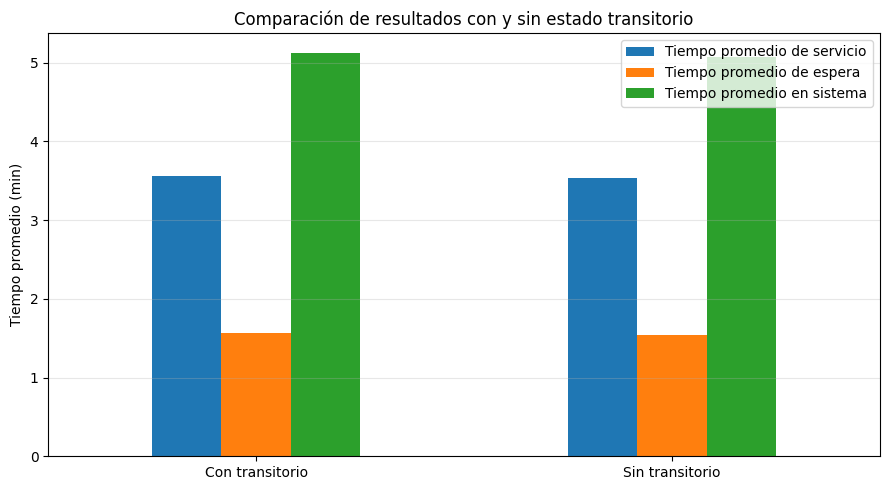

Gráfica guardada en: resultados_parqueadero/graficas/comparacion_con_sin_transitorio.png


In [59]:
comparacion_grafica = comparacion_transitorio.set_index("Etapa")

comparacion_grafica.plot(kind="bar", figsize=(9, 5))

plt.title("Comparación de resultados con y sin estado transitorio")
plt.ylabel("Tiempo promedio (min)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_grafica_transitorio = os.path.join(carpeta_graficas, "comparacion_con_sin_transitorio.png")
plt.savefig(ruta_grafica_transitorio, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_transitorio)

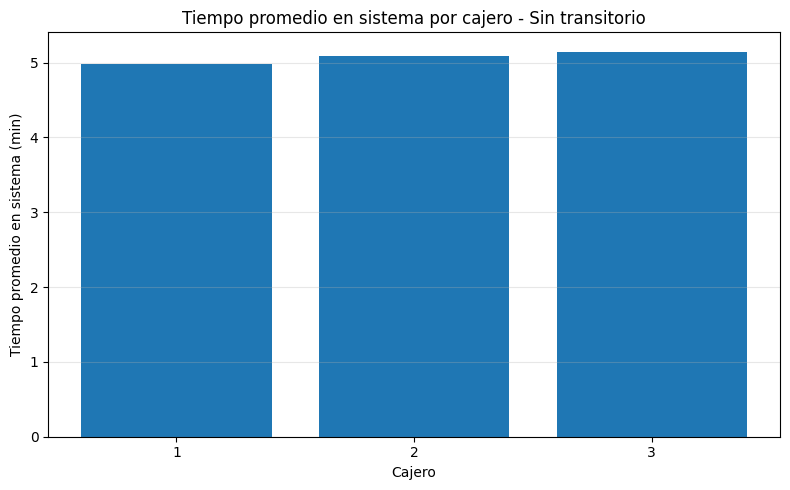

Gráfica guardada en: resultados_parqueadero/graficas/tiempo_promedio_por_cajero.png


In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    resumen_cajeros_estable_simple["cajero"].astype(str),
    resumen_cajeros_estable_simple["tiempo_sistema_media"]
)

plt.title("Tiempo promedio en sistema por cajero - Sin transitorio")
plt.xlabel("Cajero")
plt.ylabel("Tiempo promedio en sistema (min)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_grafica_cajeros = os.path.join(carpeta_graficas, "tiempo_promedio_por_cajero.png")
plt.savefig(ruta_grafica_cajeros, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_cajeros)

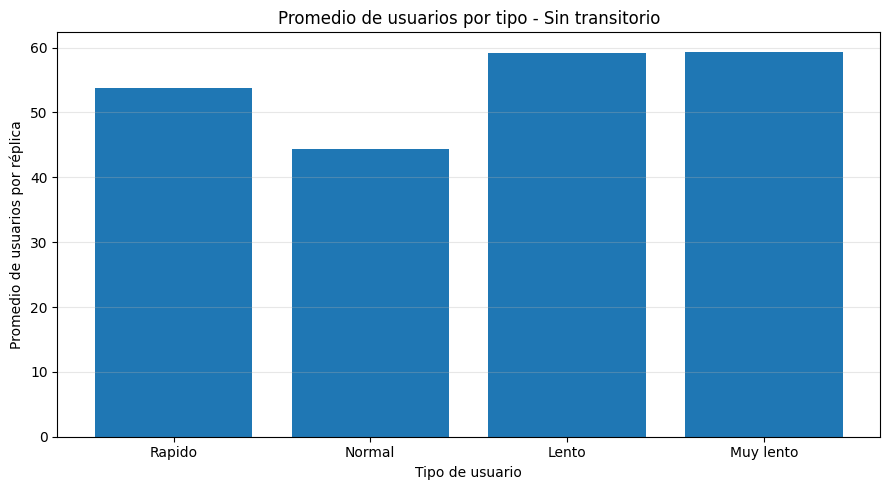

Gráfica guardada en: resultados_parqueadero/graficas/usuarios_por_tipo.png


In [61]:
plt.figure(figsize=(9, 5))

plt.bar(
    comparacion_usuarios_tipo_estable["tipo_usuario"].astype(str),
    comparacion_usuarios_tipo_estable["promedio_usuarios_por_replica"]
)

plt.title("Promedio de usuarios por tipo - Sin transitorio")
plt.xlabel("Tipo de usuario")
plt.ylabel("Promedio de usuarios por réplica")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_grafica_usuarios = os.path.join(carpeta_graficas, "usuarios_por_tipo.png")
plt.savefig(ruta_grafica_usuarios, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_usuarios)

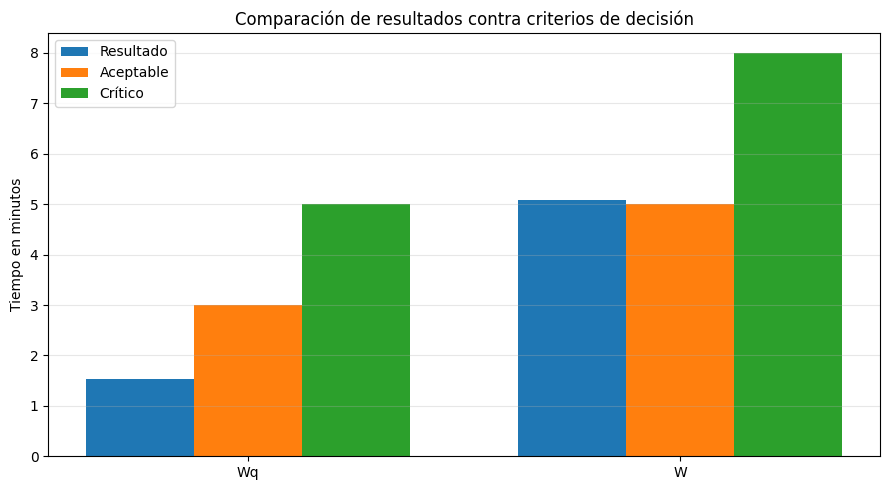

Gráfica guardada en: resultados_parqueadero/graficas/comparacion_criterios_decision.png


In [62]:
metricas_comparar = pd.DataFrame({
    "Métrica": ["Wq", "W"],
    "Resultado": [Wq, W],
    "Aceptable": [
        criterios_decision["Wq aceptable"],
        criterios_decision["W aceptable"]
    ],
    "Crítico": [
        criterios_decision["Wq crítico"],
        criterios_decision["W crítico"]
    ]
})

x = np.arange(len(metricas_comparar))
ancho = 0.25

plt.figure(figsize=(9, 5))

plt.bar(x - ancho, metricas_comparar["Resultado"], width=ancho, label="Resultado")
plt.bar(x, metricas_comparar["Aceptable"], width=ancho, label="Aceptable")
plt.bar(x + ancho, metricas_comparar["Crítico"], width=ancho, label="Crítico")

plt.xticks(x, metricas_comparar["Métrica"])
plt.ylabel("Tiempo en minutos")
plt.title("Comparación de resultados contra criterios de decisión")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

ruta_grafica_decision = os.path.join(carpeta_graficas, "comparacion_criterios_decision.png")
plt.savefig(ruta_grafica_decision, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_decision)

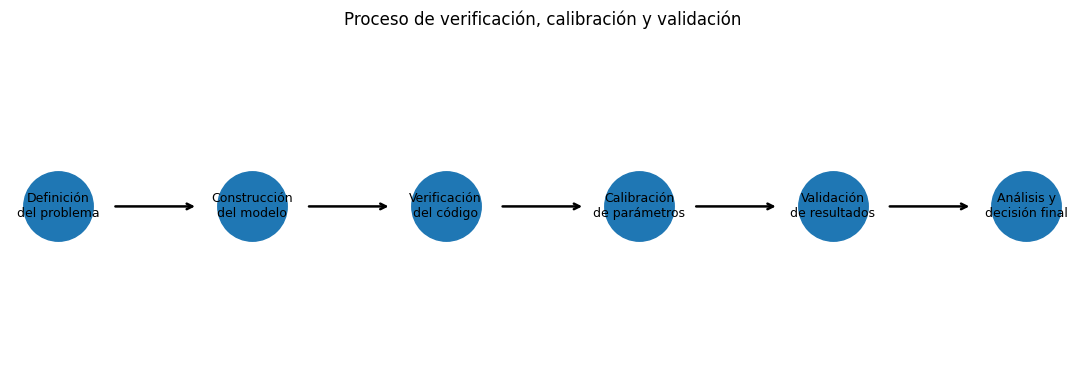

Gráfica guardada en: resultados_parqueadero/graficas/diagrama_verificacion_calibracion_validacion.png


In [63]:
plt.figure(figsize=(11, 4))

pasos = [
    "Definición\ndel problema",
    "Construcción\ndel modelo",
    "Verificación\ndel código",
    "Calibración\nde parámetros",
    "Validación\nde resultados",
    "Análisis y\ndecisión final"
]

x = np.arange(len(pasos))
y = np.ones(len(pasos))

plt.scatter(x, y, s=2500)

for i, paso in enumerate(pasos):
    plt.text(
        x[i],
        y[i],
        paso,
        ha="center",
        va="center",
        fontsize=9
    )

for i in range(len(pasos) - 1):
    plt.annotate(
        "",
        xy=(x[i + 1] - 0.28, y[i]),
        xytext=(x[i] + 0.28, y[i]),
        arrowprops=dict(arrowstyle="->", lw=1.8)
    )

plt.title("Proceso de verificación, calibración y validación")
plt.axis("off")
plt.tight_layout()

ruta_grafica_vcv = os.path.join(carpeta_graficas, "diagrama_verificacion_calibracion_validacion.png")
plt.savefig(ruta_grafica_vcv, dpi=300, bbox_inches="tight")
plt.show()

print("Gráfica guardada en:", ruta_grafica_vcv)

In [64]:
for raiz, carpetas, archivos in os.walk(carpeta_salida):
    nivel = raiz.replace(carpeta_salida, "").count(os.sep)
    sangria = "  " * nivel
    print(f"{sangria}{os.path.basename(raiz)}/")

    for archivo in archivos:
        print(f"{sangria}  {archivo}")

resultados_parqueadero/
  tabla_decision.csv
  tabla_usuarios_tipo.csv
  tabla_cajeros.csv
  tabla_parametros.csv
  tabla_validacion.csv
  tabla_metricas_generales.csv
  tabla_verificacion.csv
  tablas_resultados_parqueadero.xlsx
  graficas/
    estado_estable_transitorio.png
    comparacion_criterios_decision.png
    usuarios_por_tipo.png
    diagrama_verificacion_calibracion_validacion.png
    comparacion_con_sin_transitorio.png
    tiempo_promedio_por_cajero.png


Con la exportación de resultados se dejan disponibles las tablas y gráficas principales para el documento final. Estos archivos permiten presentar los resultados de forma ordenada y facilitan la sustentación del análisis realizado en la simulación.

## Cierre del análisis técnico

Con la simulación desarrollada se logró modelar el sistema de parqueaderos con tres cajeros independientes bajo el enfoque M/M/1. A partir de las réplicas ejecutadas se calcularon estadísticas por cajero, promedios por tipo de usuario, análisis del estado transitorio, métricas generales y criterios de decisión.

Los resultados muestran que los tres cajeros permiten operar el sistema en condiciones aceptables para el tiempo promedio de espera. Sin embargo, el tiempo promedio total en el sistema queda ligeramente por encima del valor aceptable definido, por lo que se recomienda una mejora preventiva orientada a reducir los tiempos de usuarios lentos y muy lentos.

Los archivos exportados al final del notebook contienen las tablas y gráficas necesarias para construir el documento final y sustentar los resultados obtenidos.

In [65]:
print("Resumen de entrega técnica")
print("-" * 40)

print("Réplicas simuladas originalmente:", df_resultados["replica"].nunique())
print("Réplicas usadas después del transitorio:", df_estable["replica"].nunique())
print("Usuarios simulados originalmente:", len(df_resultados))
print("Usuarios usados después del transitorio:", len(df_estable))

print("\nTablas principales:")
print("tabla_parametros:", tabla_parametros.shape)
print("resumen_cajeros_estable_simple:", resumen_cajeros_estable_simple.shape)
print("comparacion_usuarios_tipo_estable:", comparacion_usuarios_tipo_estable.shape)
print("metricas_generales_estables:", metricas_generales_estables.shape)
print("tabla_decision:", tabla_decision.shape)
print("tabla_verificacion:", tabla_verificacion.shape)
print("tabla_validacion:", tabla_validacion.shape)

print("\nDecisión final:")
print(decision_final)

Resumen de entrega técnica
----------------------------------------
Réplicas simuladas originalmente: 120
Réplicas usadas después del transitorio: 108
Usuarios simulados originalmente: 25952
Usuarios usados después del transitorio: 23395

Tablas principales:
tabla_parametros: (4, 7)
resumen_cajeros_estable_simple: (3, 7)
comparacion_usuarios_tipo_estable: (4, 5)
metricas_generales_estables: (7, 2)
tabla_decision: (4, 5)
tabla_verificacion: (5, 3)
tabla_validacion: (4, 4)

Decisión final:
Los tres cajeros permiten operar el sistema, pero se recomienda una mejora preventiva porque al menos una métrica se encuentra en zona de alerta.


In [66]:
for raiz, carpetas, archivos in os.walk(carpeta_salida):
    nivel = raiz.replace(carpeta_salida, "").count(os.sep)
    sangria = "  " * nivel
    print(f"{sangria}{os.path.basename(raiz)}/")

    for archivo in archivos:
        print(f"{sangria}  {archivo}")

resultados_parqueadero/
  tabla_decision.csv
  tabla_usuarios_tipo.csv
  tabla_cajeros.csv
  tabla_parametros.csv
  tabla_validacion.csv
  tabla_metricas_generales.csv
  tabla_verificacion.csv
  tablas_resultados_parqueadero.xlsx
  graficas/
    estado_estable_transitorio.png
    comparacion_criterios_decision.png
    usuarios_por_tipo.png
    diagrama_verificacion_calibracion_validacion.png
    comparacion_con_sin_transitorio.png
    tiempo_promedio_por_cajero.png
